In [1]:
import matplotlib.pyplot as plt
%matplotlib inline

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import numpy as np

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print(f"Formato dos dados de treino: {x_train.shape}")
print(f"Formato dos dados de teste: {x_test.shape}")
print(f"Labels originais únicos: {np.unique(y_train)}")

2025-08-23 02:55:15.576982: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-23 02:55:21.872362: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-23 02:55:25.337343: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755917730.347400    2761 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755917731.619026    2761 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1755917743.105727    2761 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

Formato dos dados de treino: (60000, 28, 28, 1)
Formato dos dados de teste: (10000, 28, 28, 1)
Labels originais únicos: [0 1 2 3 4 5 6 7 8 9]


In [2]:
def convert_to_binary(labels):
    cold_classes = [1, 2, 4, 9]
    
    hot_classes = [0, 3, 5, 6, 7, 8]
    
    binary_labels = np.zeros_like(labels)
    
    for i, label in enumerate(labels):
        if label in cold_classes:
            binary_labels[i] = 0  
        else: 
            binary_labels[i] = 1 
    
    return binary_labels

y_train_binary = convert_to_binary(y_train)
y_test_binary = convert_to_binary(y_test)

print(f"FRIO (0): {np.sum(y_train_binary == 0)} amostras")
print(f"CALOR (1): {np.sum(y_train_binary == 1)} amostras")

print(f"FRIO (0): {np.sum(y_test_binary == 0)} amostras") 
print(f"CALOR (1): {np.sum(y_test_binary == 1)} amostras")

FRIO (0): 24000 amostras
CALOR (1): 36000 amostras
FRIO (0): 4000 amostras
CALOR (1): 6000 amostras


In [3]:

def create_cnn_model():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        MaxPooling2D((2, 2)),
        
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        
        Conv2D(64, (3, 3), activation='relu'),
        
        Flatten(),
        
        Dense(64, activation='relu'),
        Dropout(0.5), 
        
        Dense(1, activation='sigmoid')
    ])
    
    return model

model = create_cnn_model()

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',  
    metrics=['accuracy']
)

model.summary()

/home/codespace/.local/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-08-23 02:56:16.008292: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,737 (362.25 KB)

 Trainable params: 92,737 (362.25 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    x_train, y_train_binary,
    batch_size=32,
    epochs=10,
    validation_data=(x_test, y_test_binary),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10


2025-08-23 02:56:16.392320: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 188160000 exceeds 10% of free system memory.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 16ms/step - accuracy: 0.8635 - loss: 0.2982 - val_accuracy: 0.9309 - val_loss: 0.1690
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.9355 - loss: 0.1587 - val_accuracy: 0.9367 - val_loss: 0.1548
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.9441 - loss: 0.1385 - val_accuracy: 0.9469 - val_loss: 0.1360
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9517 - loss: 0.1187 - val_accuracy: 0.9444 - val_loss: 0.1405
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9543 - loss: 0.1130 - val_accuracy: 0.9495 - val_loss: 0.1311
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9592 - loss: 0.1013 - val_accuracy: 0.9498 - val_loss: 0.1355
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9632 - loss: 0.0952 - val_accuracy: 0.9371 - val_loss: 0.1600
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.9648 - loss: 0.08


Acurácia no conjunto de teste: 0.9495
Loss no conjunto de teste: 0.1311


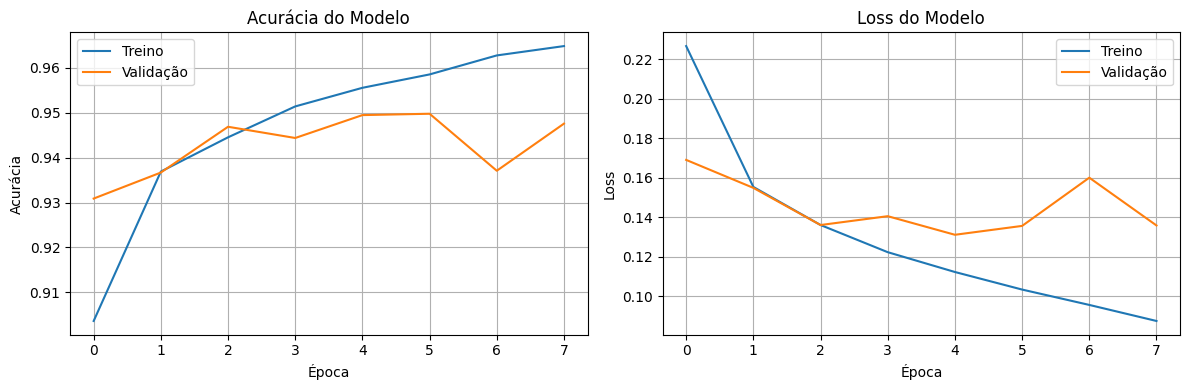

In [5]:
test_loss, test_accuracy = model.evaluate(x_test, y_test_binary, verbose=0)
print(f"\nAcurácia no conjunto de teste: {test_accuracy:.4f}")
print(f"Loss no conjunto de teste: {test_loss:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Treino')
ax1.plot(history.history['val_accuracy'], label='Validação')
ax1.set_title('Acurácia do Modelo')
ax1.set_xlabel('Época')
ax1.set_ylabel('Acurácia')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Treino')
ax2.plot(history.history['val_loss'], label='Validação')
ax2.set_title('Loss do Modelo')
ax2.set_xlabel('Época')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

 21/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

2025-08-23 03:00:53.673829: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 31360000 exceeds 10% of free system memory.


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Exemplos de predições (verde = correto, vermelho = incorreto):


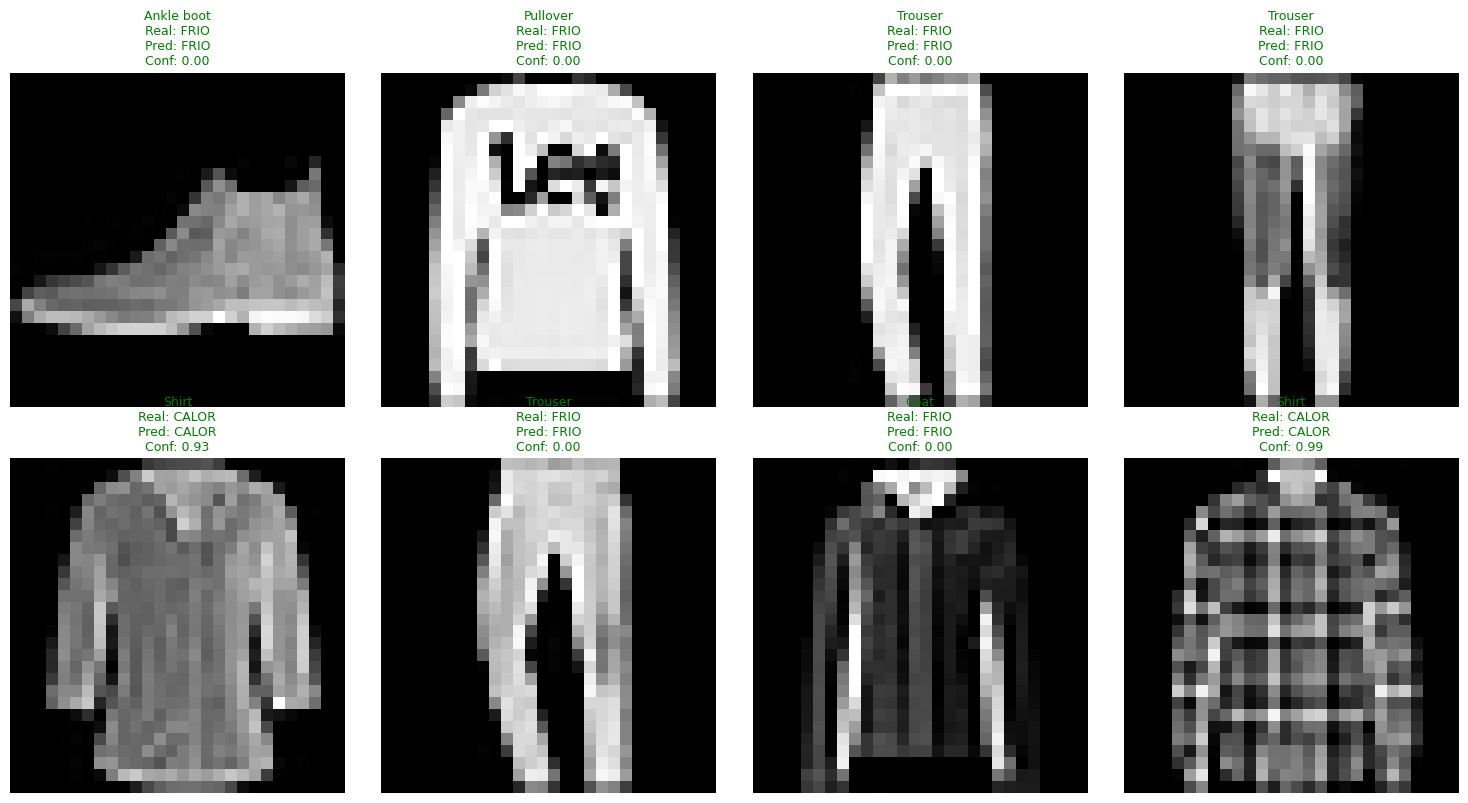


Matriz de Confusão:
Predito:
       FRIO  CALOR
FRIO   3767   233
CALOR   272  5728

Relatório de Classificação:
              precision    recall  f1-score   support

        FRIO       0.93      0.94      0.94      4000
       CALOR       0.96      0.95      0.96      6000

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000



In [6]:

predictions = model.predict(x_test)
predicted_classes = (predictions > 0.5).astype(int).flatten()

class_names_original = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
                       'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
binary_class_names = ['FRIO', 'CALOR']

def show_predictions(num_examples=8):
    """
    Mostra exemplos de predições do modelo
    """
    plt.figure(figsize=(15, 8))
    
    for i in range(num_examples):
        plt.subplot(2, 4, i + 1)
        
        plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
        
        true_class = class_names_original[y_test[i]]
        true_binary = binary_class_names[y_test_binary[i]]
        pred_binary = binary_class_names[predicted_classes[i]]
        confidence = predictions[i][0]
        
        color = 'green' if predicted_classes[i] == y_test_binary[i] else 'red'
        plt.title(f'{true_class}\nReal: {true_binary}\nPred: {pred_binary}\nConf: {confidence:.2f}', 
                 color=color, fontsize=9)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

print("Exemplos de predições (verde = correto, vermelho = incorreto):")
show_predictions()

from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test_binary, predicted_classes)
print("\nMatriz de Confusão:")
print("Predito:")
print("       FRIO  CALOR")
print(f"FRIO   {cm[0,0]:4d}  {cm[0,1]:4d}")
print(f"CALOR  {cm[1,0]:4d}  {cm[1,1]:4d}")

print("\nRelatório de Classificação:")
print(classification_report(y_test_binary, predicted_classes, 
                          target_names=['FRIO', 'CALOR']))

In [7]:
def predict_temperature_suitability(model, image_index=None, image_array=None):
    """
    Prediz se uma roupa é adequada para FRIO ou CALOR
    
    Args:
        model: modelo treinado
        image_index: índice da imagem no conjunto de teste (opcional)
        image_array: array da imagem normalizada (opcional)
    
    Returns:
        tuple: (classe_predita, confiança, classe_original)
    """
    if image_index is not None:
        image = x_test[image_index:image_index+1]
        original_class = class_names_original[y_test[image_index]]
    elif image_array is not None:
        if image_array.shape == (28, 28):
            image = image_array.reshape(1, 28, 28, 1)
        else:
            image = image_array
        original_class = "Desconhecida"
    else:
        raise ValueError("Deve fornecer image_index OU image_array")
    
    prediction = model.predict(image, verbose=0)
    confidence = prediction[0][0]
    predicted_class = "CALOR" if confidence > 0.5 else "FRIO"
    
    return predicted_class, confidence, original_class

print("Exemplo de uso da função de predição:")
for i in [0, 1, 2, 3, 4]:
    pred_class, confidence, orig_class = predict_temperature_suitability(model, image_index=i)
    print(f"Imagem {i}: {orig_class} -> Predição: {pred_class} (confiança: {confidence:.3f})")

print(f"\nModelo treinado com sucesso!")
print(f"Acurácia final: {test_accuracy:.4f}")
print(f"O modelo pode classificar roupas como adequadas para FRIO ou CALOR")

Exemplo de uso da função de predição:
Imagem 0: Ankle boot -> Predição: FRIO (confiança: 0.000)
Imagem 1: Pullover -> Predição: FRIO (confiança: 0.002)
Imagem 2: Trouser -> Predição: FRIO (confiança: 0.000)
Imagem 3: Trouser -> Predição: FRIO (confiança: 0.000)
Imagem 4: Shirt -> Predição: CALOR (confiança: 0.929)

Modelo treinado com sucesso!
Acurácia final: 0.9495
O modelo pode classificar roupas como adequadas para FRIO ou CALOR
